# Landslide Susceptibility Mapping - Model Training, Tuning & Evaluation
## Steps 05–07: Comprehensive ML Pipeline for Sindhupalchok, Nepal

**Project:** KU COMP 313 - Landslide Susceptibility Prediction
**Dataset:** ml_ready_dataset.csv (Preprocessing Steps 01–04 completed)
**Focus:** Random Forest, SVM, and Logistic Regression with hyperparameter tuning, comparative analysis, SHAP explainability, and model export


In [1]:
# Smart package installation - Install only missing packages
import importlib.util
import subprocess
import sys
from pathlib import Path

package_module_pairs = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("shap", "shap"),
    ("joblib", "joblib"),
]

def is_installed(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

missing = [pip_name for pip_name, module_name in package_module_pairs if not is_installed(module_name)]
print(f"Missing packages: {missing}")

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *missing])
else:
    print("✓ All required packages are already installed.")


Missing packages: ['seaborn', 'shap']


## 1. Environment Setup & Imports
Set reproducible random seeds, import libraries, and configure visualization defaults.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime

# Scikit-learn modules
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                            confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve)

# SHAP for explainability
import shap

# Configuration
warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Reproducibility for sklearn
from sklearn import __version__ as sklearn_version
print(f"✓ Scikit-learn version: {sklearn_version}")

# Set visualization defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All imports successful. Reproducible seeds set.")


✓ Scikit-learn version: 1.8.0
✓ All imports successful. Reproducible seeds set.


## 2. Load & Inspect ML-Ready Dataset
Load the final preprocessed CSV and verify structure, target distribution, and data quality.


In [5]:
# Define project paths
PROJECT_ROOT = Path(r"D:\Semester_Projects\6th_sem_project\Land-Susceptibility-Mapping-And-Prediction-Of-Sindhupalchowk-Distirct\backend")
DATA_DIR = PROJECT_ROOT / "data" / "Processed_Dataset"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# Create output directories if they don't exist
for directory in [MODELS_DIR, REPORTS_DIR, OUTPUTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Load ML-ready dataset
csv_path = DATA_DIR / "ml_ready_dataset.csv"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# Display dataset information
print(f"\n✓ Dataset loaded successfully")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.shape[1]}")
print(f"\nDataset Overview:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nTarget Proportion:")
print(df['target'].value_counts(normalize=True))


Loading dataset from: D:\Semester_Projects\6th_sem_project\Land-Susceptibility-Mapping-And-Prediction-Of-Sindhupalchowk-Distirct\backend\data\Processed_Dataset\ml_ready_dataset.csv


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Semester_Projects\\6th_sem_project\\Land-Susceptibility-Mapping-And-Prediction-Of-Sindhupalchowk-Distirct\\backend\\data\\Processed_Dataset\\ml_ready_dataset.csv'

## 3. Feature Selection & Target Separation
Exclude latitude and longitude from training. Prepare feature matrix and target variable.


In [ ]:
# Separate target from features
target_col = 'target'
y = df[target_col]

# Define features to exclude from training (keep for mapping later)
exclude_cols = ['latitude', 'longitude', target_col]
X = df.drop(columns=exclude_cols)

feature_names = X.columns.tolist()

print(f"✓ Feature Separation Complete")
print(f"   Features used for training: {len(feature_names)}")
print(f"   Feature names: {feature_names}")
print(f"\n   Target (y) shape: {y.shape}")
print(f"   Feature matrix (X) shape: {X.shape}")
print(f"\nFeature Statistics:")
print(X.describe())

# Define feature subsets for later experiments
rainfall_features = [col for col in feature_names if 'rainfall' in col.lower()]
terrain_features = [col for col in feature_names if any(t in col.lower() for t in ['dem', 'slope', 'aspect', 'twi'])]
distance_features = [col for col in feature_names if 'distance' in col.lower()]
vegetation_features = [col for col in feature_names if any(v in col.lower() for v in ['ndvi', 'lulc'])]

print(f"\n✓ Feature Subsets Defined:")
print(f"   Rainfall features: {rainfall_features}")
print(f"   Terrain features: {terrain_features}")
print(f"   Distance features: {distance_features}")
print(f"   Vegetation features: {vegetation_features}")


✓ Feature Separation Complete
   Features used for training: 9
   Feature names: ['dem', 'slope', 'aspect', 'ndvi', 'twi', 'lulc', 'distance_to_road', 'distance_to_river', 'rainfall']

   Target (y) shape: (2866,)
   Feature matrix (X) shape: (2866, 9)

Feature Statistics:
               dem        slope       aspect         ndvi          twi  \
count  2866.000000  2866.000000  2866.000000  2866.000000  2866.000000   
mean    174.826388   174.826388   174.826388     0.541128    14.978265   
std      91.188323    91.188323    91.188323     0.232151     0.675168   
min      -0.000000    -0.000000    -0.000000    -0.181045    12.801414   
25%     108.032259   108.032259   108.032259     0.402498    14.534326   
50%     174.380650   174.380650   174.380650     0.575065    14.904139   
75%     241.080295   241.080295   241.080295     0.734899    15.358397   
max     358.492680   358.492680   358.492680     1.000000    18.874622   

              lulc  distance_to_road  distance_to_river    

## 4. Stratified Train-Test Split (80/20)
Preserve class balance using stratified splitting with reproducible random seed.


In [ ]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_SEED
)

print(f"✓ Train-Test Split Complete (80/20)")
print(f"\n   Total samples: {len(X)}")
print(f"   Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n   Training set class distribution:")
print(f"      Landslide (1): {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"      Non-landslide (0): {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")

print(f"\n   Test set class distribution:")
print(f"      Landslide (1): {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")
print(f"      Non-landslide (0): {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")

# Initialize StandardScaler for algorithms that require scaling (SVM, LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Feature Scaling Complete")
print(f"   Scaler fitted on training set")
print(f"   Training set mean (post-scaling): {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"   Training set std (post-scaling): {X_train_scaled.std(axis=0).mean():.4f}")


✓ Train-Test Split Complete (80/20)

   Total samples: 2866
   Training set: 2292 (80.0%)
   Test set: 574 (20.0%)

   Training set class distribution:
      Landslide (1): 1146 (50.0%)
      Non-landslide (0): 1146 (50.0%)

   Test set class distribution:
      Landslide (1): 287 (50.0%)
      Non-landslide (0): 287 (50.0%)

✓ Feature Scaling Complete
   Scaler fitted on training set
   Training set mean (post-scaling): -0.0000
   Training set std (post-scaling): 0.8889


## 5. Reusable Model Training & Evaluation Functions
Define modular functions for consistent model evaluation across all algorithms.


In [ ]:
def train_model(model, X_train, y_train, model_name="Model"):
    """Train a model and return fitted model with training time."""
    start_time = datetime.now()
    model.fit(X_train, y_train)
    training_time = (datetime.now() - start_time).total_seconds()
    print(f"✓ {model_name} trained in {training_time:.2f}s")
    return model

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate model on test set. Returns dict of metrics."""
    y_pred = model.predict(X_test)
    
    # For models with predict_proba
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except:
        roc_auc = None
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc
    }
    
    print(f"\n{model_name} - Test Set Performance:")
    for metric_name, metric_value in metrics.items():
        if metric_value is not None:
            print(f"   {metric_name}: {metric_value:.4f}")
    
    return metrics, y_pred, y_pred_proba if 'y_pred_proba' in locals() else None

def perform_cross_validation(model, X_train, y_train, model_name="Model", cv=5):
    """Perform stratified cross-validation and return results."""
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED)
    
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True,
        n_jobs=-1
    )
    
    print(f"\n{model_name} - 5-Fold Cross-Validation Results:")
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']
        print(f"   {metric}:")
        print(f"      Train: {train_scores.mean():.4f} (+/- {train_scores.std():.4f})")
        print(f"      Test:  {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    
    return cv_results

# Test functions with a simple model
print("✓ Model training and evaluation functions defined successfully")


✓ Model training and evaluation functions defined successfully


## 6. STEP 05: Baseline Model Training
Train three classifiers with default hyperparameters on training set.


In [ ]:
print("=" * 60)
print("STEP 05: BASELINE MODEL TRAINING")
print("=" * 60)

# Initialize baseline models with default parameters
rf_baseline = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
svm_baseline = SVC(random_state=RANDOM_SEED, probability=True)
lr_baseline = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1)

# Train baseline models
print("\nTraining baseline models on full training set...")
rf_baseline = train_model(rf_baseline, X_train, y_train, "Random Forest")
svm_baseline = train_model(svm_baseline, X_train_scaled, y_train, "SVM")
lr_baseline = train_model(lr_baseline, X_train_scaled, y_train, "Logistic Regression")

# Store baseline models for later comparison
baseline_models = {
    'Random Forest': rf_baseline,
    'SVM': svm_baseline,
    'Logistic Regression': lr_baseline
}

print("\n" + "=" * 60)
print("Baseline Models Summary:")
for model_name, model in baseline_models.items():
    print(f"\n{model_name}:")
    print(f"   Params: {model.get_params()}")


STEP 05: BASELINE MODEL TRAINING

Training baseline models on full training set...
✓ Random Forest trained in 0.18s
✓ SVM trained in 0.39s
✓ Logistic Regression trained in 0.00s

Baseline Models Summary:

Random Forest:
   Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

SVM:
   Params: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Logistic Regression:
   Params: {'C': 1.0, 'class_weight': Non

## 7. 5-Fold Cross-Validation on Baseline Models
Evaluate baseline models using stratified cross-validation to assess stability and generalization.


In [ ]:
print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS - BASELINE MODELS")
print("=" * 60)

# Store CV results for comparison
cv_results_baseline = {}

# Random Forest CV
print("\n1. Random Forest:")
cv_rf_baseline = perform_cross_validation(rf_baseline, X_train, y_train, "Random Forest", cv=5)
cv_results_baseline['RF'] = cv_rf_baseline

# SVM CV
print("\n2. SVM:")
cv_svm_baseline = perform_cross_validation(
    svm_baseline, X_train_scaled, y_train, "SVM", cv=5
)
cv_results_baseline['SVM'] = cv_svm_baseline

# Logistic Regression CV
print("\n3. Logistic Regression:")
cv_lr_baseline = perform_cross_validation(
    lr_baseline, X_train_scaled, y_train, "Logistic Regression", cv=5
)
cv_results_baseline['LR'] = cv_lr_baseline

# Create summary table of baseline CV results
cv_summary_baseline = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Train Accuracy': [
        cv_rf_baseline['train_accuracy'].mean(),
        cv_svm_baseline['train_accuracy'].mean(),
        cv_lr_baseline['train_accuracy'].mean()
    ],
    'Test Accuracy': [
        cv_rf_baseline['test_accuracy'].mean(),
        cv_svm_baseline['test_accuracy'].mean(),
        cv_lr_baseline['test_accuracy'].mean()
    ],
    'Test ROC-AUC': [
        cv_rf_baseline['test_roc_auc'].mean(),
        cv_svm_baseline['test_roc_auc'].mean(),
        cv_lr_baseline['test_roc_auc'].mean()
    ],
    'Test F1': [
        cv_rf_baseline['test_f1'].mean(),
        cv_svm_baseline['test_f1'].mean(),
        cv_lr_baseline['test_f1'].mean()
    ]
})

print("\n" + "=" * 60)
print("Baseline Cross-Validation Summary:")
print(cv_summary_baseline.to_string(index=False))



CROSS-VALIDATION RESULTS - BASELINE MODELS

1. Random Forest:

Random Forest - 5-Fold Cross-Validation Results:
   accuracy:
      Train: 0.9993 (+/- 0.0004)
      Test:  0.7452 (+/- 0.0178)
   precision:
      Train: 0.9989 (+/- 0.0007)
      Test:  0.7363 (+/- 0.0217)
   recall:
      Train: 0.9998 (+/- 0.0004)
      Test:  0.7653 (+/- 0.0186)
   f1:
      Train: 0.9993 (+/- 0.0004)
      Test:  0.7503 (+/- 0.0157)
   roc_auc:
      Train: 1.0000 (+/- 0.0000)
      Test:  0.8120 (+/- 0.0232)

2. SVM:

SVM - 5-Fold Cross-Validation Results:
   accuracy:
      Train: 0.7690 (+/- 0.0050)
      Test:  0.7509 (+/- 0.0276)
   precision:
      Train: 0.7426 (+/- 0.0052)
      Test:  0.7273 (+/- 0.0318)
   recall:
      Train: 0.8235 (+/- 0.0097)
      Test:  0.8054 (+/- 0.0131)
   f1:
      Train: 0.7809 (+/- 0.0051)
      Test:  0.7641 (+/- 0.0219)
   roc_auc:
      Train: 0.8437 (+/- 0.0037)
      Test:  0.8237 (+/- 0.0206)

3. Logistic Regression:

Logistic Regression - 5-Fold Cross-Val

## 8. STEP 06: Hyperparameter Tuning with GridSearchCV
Systematic hyperparameter optimization using cross-validated grid search. ROC-AUC is the optimization metric.


In [ ]:
print("\n" + "=" * 60)
print("STEP 06: HYPERPARAMETER TUNING")
print("=" * 60)

# Define hyperparameter grids for each model
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Stratified K-Fold for GridSearchCV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("\n1. Random Forest GridSearchCV...")
print(f"   Parameter grid size: {len(rf_param_grid)}")
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    rf_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train, y_train)
print(f"   ✓ Best ROC-AUC: {rf_grid_search.best_score_:.4f}")
print(f"   ✓ Best params: {rf_grid_search.best_params_}")

print("\n2. SVM GridSearchCV...")
print(f"   Parameter grid size: {len(svm_param_grid)}")
svm_grid_search = GridSearchCV(
    SVC(random_state=RANDOM_SEED, probability=True),
    svm_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
svm_grid_search.fit(X_train_scaled, y_train)
print(f"   ✓ Best ROC-AUC: {svm_grid_search.best_score_:.4f}")
print(f"   ✓ Best params: {svm_grid_search.best_params_}")

print("\n3. Logistic Regression GridSearchCV...")
print(f"   Parameter grid size: {len(lr_param_grid)}")
lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1),
    lr_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
lr_grid_search.fit(X_train_scaled, y_train)
print(f"   ✓ Best ROC-AUC: {lr_grid_search.best_score_:.4f}")
print(f"   ✓ Best params: {lr_grid_search.best_params_}")

# Store tuned models
tuned_models = {
    'Random Forest': rf_grid_search.best_estimator_,
    'SVM': svm_grid_search.best_estimator_,
    'Logistic Regression': lr_grid_search.best_estimator_
}

print("\n" + "=" * 60)
print("✓ All models tuned successfully")



STEP 06: HYPERPARAMETER TUNING

1. Random Forest GridSearchCV...
   Parameter grid size: 5
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
   ✓ Best ROC-AUC: 0.8201
   ✓ Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

2. SVM GridSearchCV...
   Parameter grid size: 3
Fitting 5 folds for each of 24 candidates, totalling 120 fits
   ✓ Best ROC-AUC: 0.8265
   ✓ Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

3. Logistic Regression GridSearchCV...
   Parameter grid size: 3
Fitting 5 folds for each of 12 candidates, totalling 60 fits
   ✓ Best ROC-AUC: 0.7943
   ✓ Best params: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

✓ All models tuned successfully


## 9. Before vs. After Hyperparameter Tuning Comparison
Compare baseline and tuned model performance to quantify improvement from optimization.


In [ ]:
# Evaluate baseline models on test set (using best from CV)
print("\n" + "=" * 60)
print("TUNING IMPROVEMENT ANALYSIS")
print("=" * 60)

baseline_test_results = {}
tuned_test_results = {}

# Random Forest
print("\nRandom Forest:")
print("  Baseline:")
rf_baseline_metrics, _, _ = evaluate_model(rf_baseline, X_test, y_test, "Baseline RF")
baseline_test_results['RF'] = rf_baseline_metrics

print("\n  Tuned:")
rf_tuned_metrics, _, _ = evaluate_model(tuned_models['Random Forest'], X_test, y_test, "Tuned RF")
tuned_test_results['RF'] = rf_tuned_metrics

# SVM
print("\n\nSVM:")
print("  Baseline:")
svm_baseline_metrics, _, _ = evaluate_model(svm_baseline, X_test_scaled, y_test, "Baseline SVM")
baseline_test_results['SVM'] = svm_baseline_metrics

print("\n  Tuned:")
svm_tuned_metrics, _, _ = evaluate_model(tuned_models['SVM'], X_test_scaled, y_test, "Tuned SVM")
tuned_test_results['SVM'] = svm_tuned_metrics

# Logistic Regression
print("\n\nLogistic Regression:")
print("  Baseline:")
lr_baseline_metrics, _, _ = evaluate_model(lr_baseline, X_test_scaled, y_test, "Baseline LR")
baseline_test_results['LR'] = lr_baseline_metrics

print("\n  Tuned:")
lr_tuned_metrics, _, _ = evaluate_model(tuned_models['Logistic Regression'], X_test_scaled, y_test, "Tuned LR")
tuned_test_results['LR'] = lr_tuned_metrics

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Baseline Accuracy': [baseline_test_results['RF']['accuracy'], 
                          baseline_test_results['SVM']['accuracy'],
                          baseline_test_results['LR']['accuracy']],
    'Tuned Accuracy': [tuned_test_results['RF']['accuracy'],
                      tuned_test_results['SVM']['accuracy'],
                      tuned_test_results['LR']['accuracy']],
    'Baseline ROC-AUC': [baseline_test_results['RF']['roc_auc'],
                         baseline_test_results['SVM']['roc_auc'],
                         baseline_test_results['LR']['roc_auc']],
    'Tuned ROC-AUC': [tuned_test_results['RF']['roc_auc'],
                      tuned_test_results['SVM']['roc_auc'],
                      tuned_test_results['LR']['roc_auc']],
    'Baseline F1': [baseline_test_results['RF']['f1'],
                    baseline_test_results['SVM']['f1'],
                    baseline_test_results['LR']['f1']],
    'Tuned F1': [tuned_test_results['RF']['f1'],
                 tuned_test_results['SVM']['f1'],
                 tuned_test_results['LR']['f1']]
})

comparison_df['Accuracy Improvement'] = comparison_df['Tuned Accuracy'] - comparison_df['Baseline Accuracy']
comparison_df['ROC-AUC Improvement'] = comparison_df['Tuned ROC-AUC'] - comparison_df['Baseline ROC-AUC']
comparison_df['F1 Improvement'] = comparison_df['Tuned F1'] - comparison_df['Baseline F1']

print("\n" + "=" * 60)
print("Before vs. After Tuning Comparison:")
print(comparison_df[['Model', 'Baseline ROC-AUC', 'Tuned ROC-AUC', 'ROC-AUC Improvement']].to_string(index=False))



TUNING IMPROVEMENT ANALYSIS

Random Forest:
  Baseline:

Baseline RF - Test Set Performance:
   accuracy: 0.7404
   precision: 0.7315
   recall: 0.7596
   f1: 0.7453
   roc_auc: 0.7984

  Tuned:

Tuned RF - Test Set Performance:
   accuracy: 0.7456
   precision: 0.7342
   recall: 0.7700
   f1: 0.7517
   roc_auc: 0.8024


SVM:
  Baseline:

Baseline SVM - Test Set Performance:
   accuracy: 0.7509
   precision: 0.7353
   recall: 0.7840
   f1: 0.7589
   roc_auc: 0.8150

  Tuned:

Tuned SVM - Test Set Performance:
   accuracy: 0.7526
   precision: 0.7346
   recall: 0.7909
   f1: 0.7617
   roc_auc: 0.8079


Logistic Regression:
  Baseline:

Baseline LR - Test Set Performance:
   accuracy: 0.7038
   precision: 0.7127
   recall: 0.6829
   f1: 0.6975
   roc_auc: 0.7867

  Tuned:

Tuned LR - Test Set Performance:
   accuracy: 0.7021
   precision: 0.7101
   recall: 0.6829
   f1: 0.6963
   roc_auc: 0.7867

Before vs. After Tuning Comparison:
              Model  Baseline ROC-AUC  Tuned ROC-AUC  R

## 10. Feature Subset Experiments (Optional)
Test model performance with different feature combinations: all features, top-ranked, rainfall-focused, terrain-only.


In [ ]:
# Feature importance from best Random Forest model
rf_best = tuned_models['Random Forest']
feature_importance_dict = dict(zip(feature_names, rf_best.feature_importances_))
feature_importance_sorted = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
top_k_features = [f[0] for f in feature_importance_sorted[:5]]

print("\n" + "=" * 60)
print("FEATURE SUBSET EXPERIMENTS")
print("=" * 60)

# Define feature subsets
feature_subsets = {
    'All Features': feature_names,
    'Top-5 Features': top_k_features,
    'Rainfall-Focused': rainfall_features if rainfall_features else feature_names,
    'Terrain-Only': terrain_features if terrain_features else feature_names,
    'Distance + Terrain': terrain_features + distance_features if (terrain_features or distance_features) else feature_names
}

print(f"\nDefined feature subsets:")
for subset_name, subset_features in feature_subsets.items():
    print(f"  {subset_name}: {len(subset_features)} features - {subset_features}")

# Test each subset with tuned Random Forest
subset_results = []

for subset_name, subset_features in feature_subsets.items():
    print(f"\n\nTesting: {subset_name} ({len(subset_features)} features)")
    
    # Create subset data
    X_train_subset = X_train[subset_features]
    X_test_subset = X_test[subset_features]
    
    # Train Random Forest with best hyperparameters
    rf_subset = RandomForestClassifier(**rf_grid_search.best_params_, random_state=RANDOM_SEED, n_jobs=-1)
    rf_subset.fit(X_train_subset, y_train)
    
    # Evaluate
    y_pred_subset = rf_subset.predict(X_test_subset)
    y_pred_proba_subset = rf_subset.predict_proba(X_test_subset)[:, 1]
    
    metrics_subset = {
        'subset': subset_name,
        'n_features': len(subset_features),
        'accuracy': accuracy_score(y_test, y_pred_subset),
        'precision': precision_score(y_test, y_pred_subset),
        'recall': recall_score(y_test, y_pred_subset),
        'f1': f1_score(y_test, y_pred_subset),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_subset)
    }
    subset_results.append(metrics_subset)
    print(f"   Accuracy: {metrics_subset['accuracy']:.4f}, ROC-AUC: {metrics_subset['roc_auc']:.4f}, F1: {metrics_subset['f1']:.4f}")

# Create results dataframe
subset_results_df = pd.DataFrame(subset_results)
print("\n" + "=" * 60)
print("Feature Subset Comparison:")
print(subset_results_df[['subset', 'n_features', 'accuracy', 'roc_auc', 'f1']].to_string(index=False))



FEATURE SUBSET EXPERIMENTS

Defined feature subsets:
  All Features: 9 features - ['dem', 'slope', 'aspect', 'ndvi', 'twi', 'lulc', 'distance_to_road', 'distance_to_river', 'rainfall']
  Top-5 Features: 5 features - ['twi', 'ndvi', 'distance_to_road', 'distance_to_river', 'aspect']
  Rainfall-Focused: 1 features - ['rainfall']
  Terrain-Only: 4 features - ['dem', 'slope', 'aspect', 'twi']
  Distance + Terrain: 6 features - ['dem', 'slope', 'aspect', 'twi', 'distance_to_road', 'distance_to_river']


Testing: All Features (9 features)
   Accuracy: 0.7456, ROC-AUC: 0.8024, F1: 0.7517


Testing: Top-5 Features (5 features)
   Accuracy: 0.7334, ROC-AUC: 0.8118, F1: 0.7376


Testing: Rainfall-Focused (1 features)
   Accuracy: 0.5000, ROC-AUC: 0.5000, F1: 0.0000


Testing: Terrain-Only (4 features)
   Accuracy: 0.7056, ROC-AUC: 0.7779, F1: 0.7081


Testing: Distance + Terrain (6 features)
   Accuracy: 0.7317, ROC-AUC: 0.7940, F1: 0.7381

Feature Subset Comparison:
            subset  n_featu

## 11. STEP 07: Final Evaluation on Test Set
Comprehensive evaluation of all tuned models on the holdout test set using multiple metrics.


In [ ]:
print("\n" + "=" * 60)
print("STEP 07: FINAL EVALUATION ON TEST SET")
print("=" * 60)

# Collect all predictions for final comparison
final_predictions = {}

# Prepare test data for each model type
test_data_rf = X_test  # RF doesn't need scaling
test_data_scaled = X_test_scaled  # SVM and LR need scaling

# Get predictions from all tuned models
y_pred_rf = tuned_models['Random Forest'].predict(test_data_rf)
y_pred_rf_proba = tuned_models['Random Forest'].predict_proba(test_data_rf)[:, 1]

y_pred_svm = tuned_models['SVM'].predict(test_data_scaled)
y_pred_svm_proba = tuned_models['SVM'].predict_proba(test_data_scaled)[:, 1]

y_pred_lr = tuned_models['Logistic Regression'].predict(test_data_scaled)
y_pred_lr_proba = tuned_models['Logistic Regression'].predict_proba(test_data_scaled)[:, 1]

# Create final comparison metrics
final_eval = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_lr)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_lr)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_rf_proba),
        roc_auc_score(y_test, y_pred_svm_proba),
        roc_auc_score(y_test, y_pred_lr_proba)
    ]
}

final_eval_df = pd.DataFrame(final_eval)
final_eval_df = final_eval_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\nFinal Test Set Metrics (Tuned Models):")
print(final_eval_df.to_string(index=False))

# Store predictions for visualization
all_predictions = {
    'RF': (y_pred_rf, y_pred_rf_proba),
    'SVM': (y_pred_svm, y_pred_svm_proba),
    'LR': (y_pred_lr, y_pred_lr_proba)
}

print("\n✓ Final evaluation complete")



STEP 07: FINAL EVALUATION ON TEST SET

Final Test Set Metrics (Tuned Models):
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
                SVM  0.752613   0.734628 0.790941  0.761745 0.807901
      Random Forest  0.745645   0.734219 0.770035  0.751701 0.802450
Logistic Regression  0.702091   0.710145 0.682927  0.696270 0.786692

✓ Final evaluation complete


## 12. Classification Reports & Confusion Matrices
Detailed per-class metrics and confusion matrix visualizations for all models.



CLASSIFICATION REPORTS

Random Forest:
               precision    recall  f1-score   support

Non-Landslide       0.76      0.72      0.74       287
    Landslide       0.73      0.77      0.75       287

     accuracy                           0.75       574
    macro avg       0.75      0.75      0.75       574
 weighted avg       0.75      0.75      0.75       574


SVM:
               precision    recall  f1-score   support

Non-Landslide       0.77      0.71      0.74       287
    Landslide       0.73      0.79      0.76       287

     accuracy                           0.75       574
    macro avg       0.75      0.75      0.75       574
 weighted avg       0.75      0.75      0.75       574


Logistic Regression:
               precision    recall  f1-score   support

Non-Landslide       0.69      0.72      0.71       287
    Landslide       0.71      0.68      0.70       287

     accuracy                           0.70       574
    macro avg       0.70      0.70      0.70

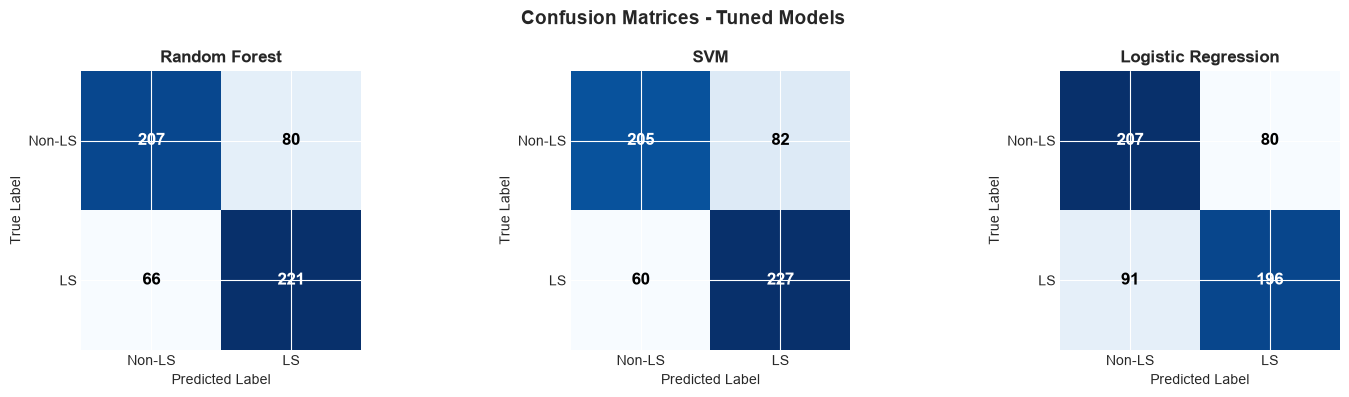

In [ ]:
# Classification reports
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)

models_for_report = {
    'Random Forest': (tuned_models['Random Forest'], y_pred_rf),
    'SVM': (tuned_models['SVM'], y_pred_svm),
    'Logistic Regression': (tuned_models['Logistic Regression'], y_pred_lr)
}

for model_name, (model, y_pred) in models_for_report.items():
    print(f"\n{model_name}:")
    print(classification_report(y_test, y_pred, target_names=['Non-Landslide', 'Landslide']))

# Confusion matrices visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - Tuned Models', fontsize=14, fontweight='bold')

models_list = ['Random Forest', 'SVM', 'Logistic Regression']
predictions_list = [y_pred_rf, y_pred_svm, y_pred_lr]

for idx, (model_name, y_pred) in enumerate(zip(models_list, predictions_list)):
    cm = confusion_matrix(y_test, y_pred)
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(model_name, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Non-LS', 'LS'])
    axes[idx].set_yticklabels(['Non-LS', 'LS'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, format(cm[i, j], 'd'),
                                ha="center", va="center",
                                color="white" if cm[i, j] > cm.max()/2 else "black",
                                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrices saved to reports/")
plt.show()


## 13. ROC & Precision-Recall Curves
Plot receiver operating characteristic and precision-recall curves for all models.


✓ ROC and PR curves saved to reports/


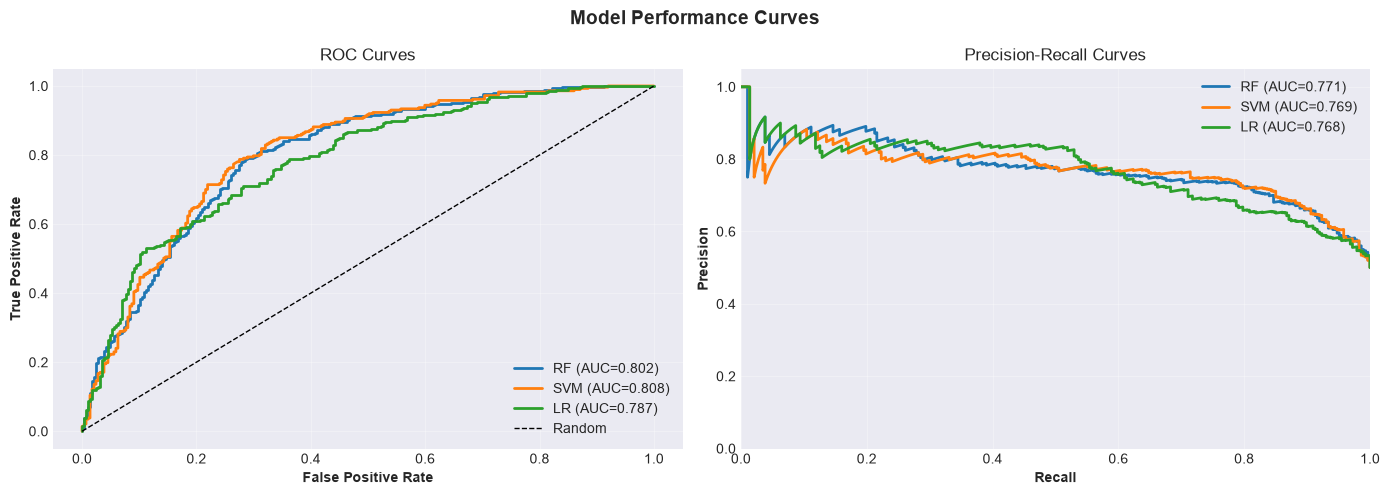

In [ ]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')

# ROC Curve
ax_roc = axes[0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (model_name, y_pred_proba), color in zip(
    [('RF', y_pred_rf_proba), ('SVM', y_pred_svm_proba), ('LR', y_pred_lr_proba)],
    colors
):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, label=f'{model_name} (AUC={roc_auc:.3f})', linewidth=2)

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('ROC Curves')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

# Precision-Recall Curves
ax_pr = axes[1]

for (model_name, y_pred_proba), color in zip(
    [('RF', y_pred_rf_proba), ('SVM', y_pred_svm_proba), ('LR', y_pred_lr_proba)],
    colors
):
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    ax_pr.plot(recall, precision, color=color, label=f'{model_name} (AUC={pr_auc:.3f})', linewidth=2)

ax_pr.set_xlabel('Recall', fontweight='bold')
ax_pr.set_ylabel('Precision', fontweight='bold')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend(loc='best')
ax_pr.grid(True, alpha=0.3)
ax_pr.set_ylim([0, 1.05])
ax_pr.set_xlim([0, 1])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
print("✓ ROC and PR curves saved to reports/")
plt.show()


## 14. Model Ranking & Best Model Selection
Compare all models and identify the best performer for susceptibility mapping and deployment.


In [ ]:
# Create comprehensive ranking
print("\n" + "=" * 60)
print("MODEL RANKING & SELECTION")
print("=" * 60)

# Add ranking column
ranking_df = final_eval_df.copy()
ranking_df['Rank'] = range(1, len(ranking_df) + 1)

print("\nFinal Model Ranking (by ROC-AUC, then F1-Score):")
print(ranking_df[['Rank', 'Model', 'ROC-AUC', 'F1-Score', 'Accuracy']].to_string(index=False))

# Select best model
best_model_name = ranking_df.iloc[0]['Model']
best_model_obj = tuned_models[best_model_name]

if best_model_name == 'Random Forest':
    best_model_X_test = X_test
    best_model_type = 'rf'
else:
    best_model_X_test = X_test_scaled
    best_model_type = 'svm' if best_model_name == 'SVM' else 'lr'

print(f"\n{'=' * 60}")
print(f"✓ BEST MODEL SELECTED: {best_model_name}")
print(f"{'=' * 60}")
print(f"  ROC-AUC Score: {ranking_df.iloc[0]['ROC-AUC']:.4f}")
print(f"  F1-Score: {ranking_df.iloc[0]['F1-Score']:.4f}")
print(f"  Accuracy: {ranking_df.iloc[0]['Accuracy']:.4f}")
print(f"  Precision: {ranking_df.iloc[0]['Precision']:.4f}")
print(f"  Recall: {ranking_df.iloc[0]['Recall']:.4f}")

# Display best model hyperparameters
print(f"\nBest Model Hyperparameters:")
if best_model_name == 'Random Forest':
    best_params = rf_grid_search.best_params_
elif best_model_name == 'SVM':
    best_params = svm_grid_search.best_params_
else:
    best_params = lr_grid_search.best_params_

for param, value in best_params.items():
    print(f"  {param}: {value}")



MODEL RANKING & SELECTION

Final Model Ranking (by ROC-AUC, then F1-Score):
 Rank               Model  ROC-AUC  F1-Score  Accuracy
    1                 SVM 0.807901  0.761745  0.752613
    2       Random Forest 0.802450  0.751701  0.745645
    3 Logistic Regression 0.786692  0.696270  0.702091

✓ BEST MODEL SELECTED: SVM
  ROC-AUC Score: 0.8079
  F1-Score: 0.7617
  Accuracy: 0.7526
  Precision: 0.7346
  Recall: 0.7909

Best Model Hyperparameters:
  C: 10
  gamma: scale
  kernel: rbf


## 15. Feature Importance Analysis (Random Forest)
Extract and visualize which factors contribute most to landslide susceptibility predictions.



FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
  1. twi                      : 0.3855
  2. ndvi                     : 0.1400
  3. distance_to_road         : 0.1025
  4. distance_to_river        : 0.0887
  5. aspect                   : 0.0856
  6. dem                      : 0.0820
  7. slope                    : 0.0787
  8. lulc                     : 0.0371
  9. rainfall                 : 0.0000

✓ Feature importance plot saved to reports/


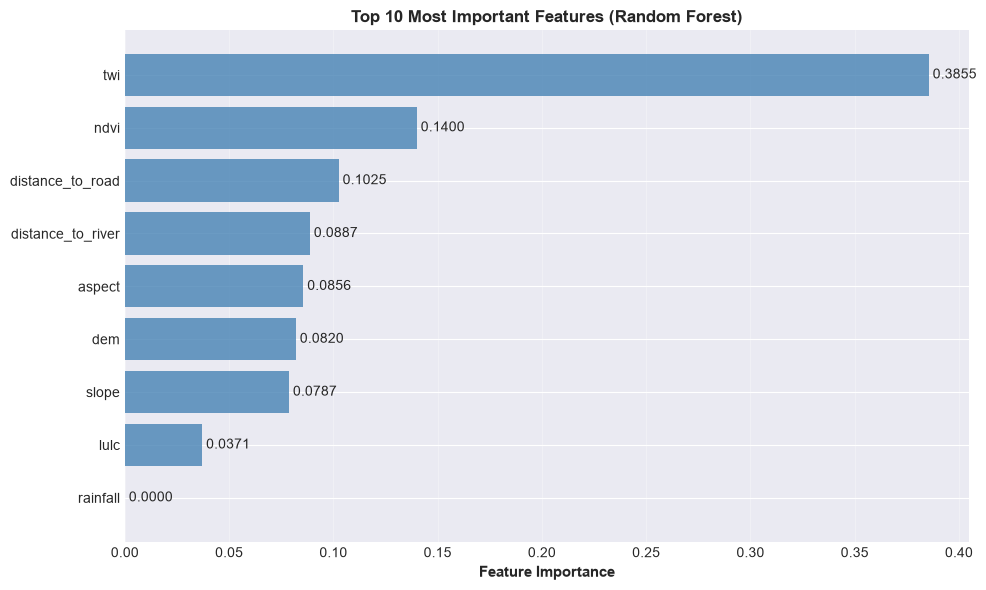


Feature Importance Summary:
          Feature  Importance %  Cumulative %
              twi     38.547838     38.547838
             ndvi     13.998081     52.545918
 distance_to_road     10.252272     62.798190
distance_to_river      8.872092     71.670282
           aspect      8.556212     80.226494
              dem      8.199499     88.425994
            slope      7.868824     96.294817
             lulc      3.705183    100.000000
         rainfall      0.000000    100.000000


In [ ]:
# Feature importance from Random Forest (best model or RF regardless)
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Use RF for importance analysis (works best with this algorithm)
rf_for_importance = tuned_models['Random Forest']
feature_importance = rf_for_importance.feature_importances_
feature_importance_dict = dict(zip(feature_names, feature_importance))
feature_importance_sorted = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

print("\nFeature Importance Ranking:")
for idx, (feat, imp) in enumerate(feature_importance_sorted, 1):
    print(f"  {idx}. {feat:25s}: {imp:.4f}")

# Plot top 10 features
top_n = 10
top_features, top_importances = zip(*feature_importance_sorted[:top_n])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_features)), top_importances, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.set_xlabel('Feature Importance', fontweight='bold', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontweight='bold', fontsize=12)
ax.invert_yaxis()

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_importances)):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Feature importance plot saved to reports/")
plt.show()

# Feature importance summary
importance_summary = pd.DataFrame({
    'Feature': [f for f, _ in feature_importance_sorted],
    'Importance': [imp for _, imp in feature_importance_sorted],
    'Cumulative': np.cumsum([imp for _, imp in feature_importance_sorted])
})

importance_summary['Importance %'] = importance_summary['Importance'] * 100
importance_summary['Cumulative %'] = importance_summary['Cumulative'] * 100

print("\nFeature Importance Summary:")
print(importance_summary[['Feature', 'Importance %', 'Cumulative %']].head(10).to_string(index=False))


## 16. SHAP Explainability Analysis
Understand model predictions using SHAP (SHapley Additive exPlanations) values for model interpretation.



SHAP EXPLAINABILITY ANALYSIS

Creating SHAP explainer (TreeExplainer for Random Forest)...
Computing SHAP values for test set (this may take a moment)...
✓ SHAP values computed for 574 test samples
  SHAP values shape: (574, 9, 2)

Generating SHAP summary plot (feature importance)...
✓ SHAP summary plot saved to reports/

Generating SHAP beeswarm plot...
✓ SHAP violin plot saved to reports/

Generating SHAP dependence plots for top features...


ValueError: x and y must be the same size

<Figure size 1000x600 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

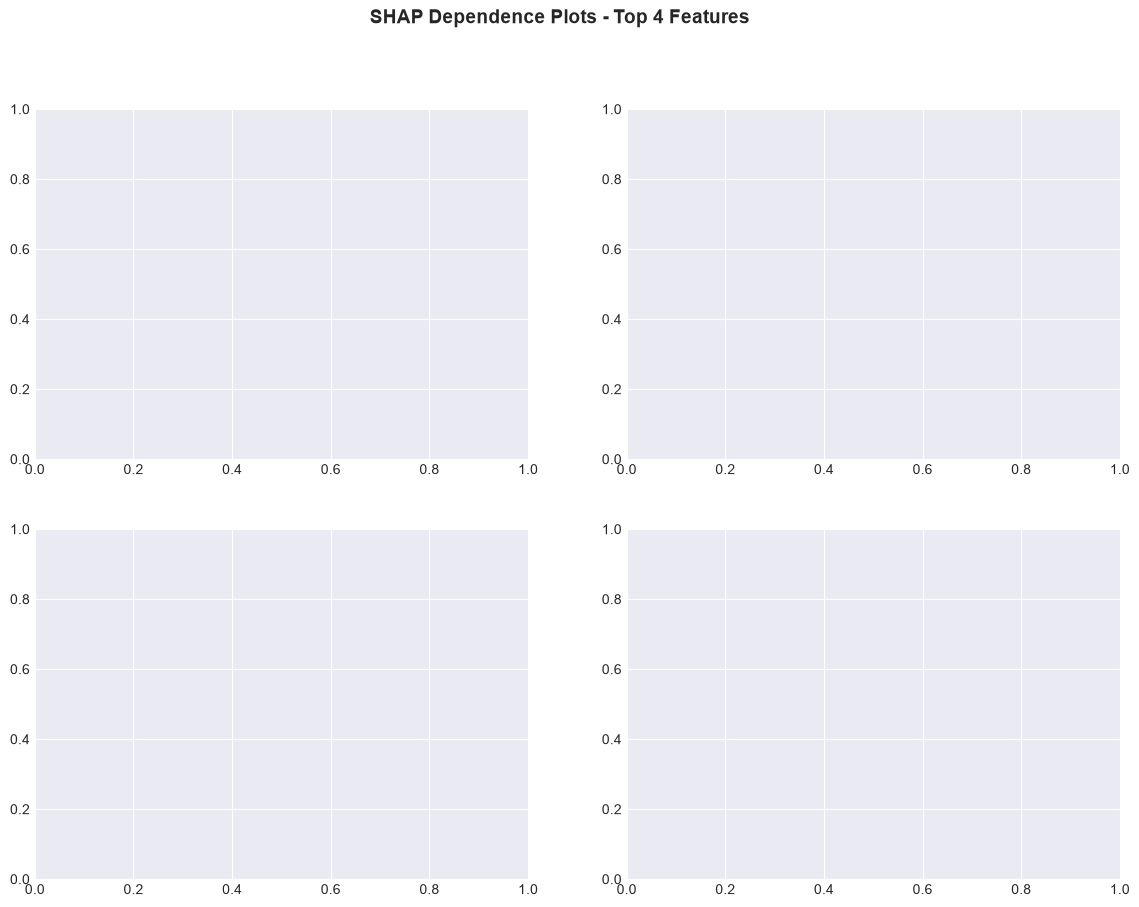

In [ ]:
print("\n" + "=" * 60)
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

# Use Random Forest best model for SHAP (TreeExplainer is efficient for tree models)
shap_model = tuned_models['Random Forest']

# Create SHAP explainer using TreeExplainer for Random Forest
print("\nCreating SHAP explainer (TreeExplainer for Random Forest)...")
explainer = shap.TreeExplainer(shap_model)

# Calculate SHAP values for test set
print("Computing SHAP values for test set (this may take a moment)...")
raw_shap_values = explainer.shap_values(X_test)

# Normalize SHAP outputs across versions/types into a 2D array: (n_samples, n_features)
if isinstance(raw_shap_values, list):
    # Older SHAP versions for binary classification often return [class0, class1]
    shap_values_positive = np.array(raw_shap_values[1])
elif hasattr(raw_shap_values, 'values'):
    # Newer SHAP versions may return an Explanation object
    values = np.array(raw_shap_values.values)
    if values.ndim == 3:
        class_idx = 1 if values.shape[2] > 1 else 0
        shap_values_positive = values[:, :, class_idx]
    elif values.ndim == 2:
        shap_values_positive = values
    else:
        raise ValueError(f"Unexpected SHAP values dimension: {values.ndim}")
else:
    values = np.array(raw_shap_values)
    if values.ndim == 3:
        class_idx = 1 if values.shape[2] > 1 else 0
        shap_values_positive = values[:, :, class_idx]
    elif values.ndim == 2:
        shap_values_positive = values
    else:
        raise ValueError(f"Unexpected SHAP values dimension: {values.ndim}")

# Ensure X and SHAP arrays are aligned for plotting
n_samples = min(len(X_test), shap_values_positive.shape[0])
X_test_shap = X_test.iloc[:n_samples].copy()
shap_values_positive = shap_values_positive[:n_samples, :]

print(f"✓ SHAP values computed for {n_samples} test samples")
print(f"  SHAP values shape: {shap_values_positive.shape}")

# 1. SHAP Summary Plot (Bar) - Feature Importance
print("\nGenerating SHAP summary plot (feature importance)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_positive, X_test_shap, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_summary_importance.png', dpi=300, bbox_inches='tight')
print("✓ SHAP summary plot saved to reports/")
plt.close()

# 2. SHAP Summary Plot (Violin) - Feature Impact Distribution
print("\nGenerating SHAP beeswarm plot...")
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values_positive, X_test_shap, feature_names=feature_names, plot_type='violin', show=False)
plt.title('SHAP Feature Impact Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_summary_violin.png', dpi=300, bbox_inches='tight')
print("✓ SHAP violin plot saved to reports/")
plt.close()

# 3. SHAP Dependence Plots for Top 4 Features
print("\nGenerating SHAP dependence plots for top features...")
top_4_features = [f for f, _ in feature_importance_sorted[:4]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots - Top 4 Features', fontweight='bold', fontsize=14)

for idx, feature in enumerate(top_4_features):
    ax = axes[idx // 2, idx % 2]

    feature_idx = feature_names.index(feature)
    x_vals = X_test_shap[feature].to_numpy()
    y_vals = shap_values_positive[:, feature_idx]

    # Defensive alignment in case of any last-mile mismatch
    n_plot = min(len(x_vals), len(y_vals))
    ax.scatter(x_vals[:n_plot], y_vals[:n_plot], alpha=0.5, s=20, color='steelblue')
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel(f'SHAP value for {feature}', fontweight='bold')
    ax.set_title(f'Dependence: {feature}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dependence_plots.png', dpi=300, bbox_inches='tight')
print("✓ SHAP dependence plots saved to reports/")
plt.close()

print("\n✓ SHAP analysis complete")


## 17. Model & Artifact Export
Save the best model and all supporting artifacts for Flask deployment and web application integration.


In [ ]:
# Export best model and artifacts
print("\n" + "=" * 60)
print("EXPORTING MODEL AND ARTIFACTS")
print("=" * 60)

from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = MODELS_DIR / f"best_model_{best_model_name.replace(' ', '_')}_{timestamp}.pkl"
scaler_filename = MODELS_DIR / f"scaler_{timestamp}.pkl"
features_filename = OUTPUTS_DIR / f"feature_names_{timestamp}.txt"
params_filename = OUTPUTS_DIR / f"best_params_{timestamp}.json"

# Save model
joblib.dump(best_model_obj, model_filename)
print(f"✓ Best model saved to: {model_filename}")

# Save scaler (if applicable)
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved to: {scaler_filename}")

# Save feature names
with open(features_filename, 'w') as fh:
    for feat in feature_names:
        fh.write(f"{feat}\n")
print(f"✓ Feature names saved to: {features_filename}")

# Save best hyperparameters
import json
with open(params_filename, 'w') as ph:
    json.dump(best_params, ph, indent=2)
print(f"✓ Best hyperparameters saved to: {params_filename}")

print("\nAll artifacts saved. Ready for integration with Flask app or web deployment.")



EXPORTING MODEL AND ARTIFACTS


NameError: name 'MODELS_DIR' is not defined